In [88]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers,models,regularizers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [89]:
(train_x,train_y),(test_x,test_y) = mnist.load_data()

In [91]:
print("train_x.shape : ",train_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (60000, 28, 28)
test_x.shape :  (10000, 28, 28)


In [92]:
train_x = train_x.reshape((train_x.shape[0],28*28)).astype('float32') / 255
test_x = test_x.reshape((10000,28*28)).astype('float32') / 255

# train_x = train_x.astype('float32') / 255
# test_x = test_x.astype('float32') / 255

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [93]:
validation_x = train_x[50000:60000]
validation_y = train_y[50000:60000]

train_x = train_x[:50000]
train_y = train_y[:50000]

print("train_x.shape : ",train_x.shape)
print("validation_x.shape : ",validation_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (50000, 784)
validation_x.shape :  (10000, 784)
test_x.shape :  (10000, 784)


In [94]:
def buildModel(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [95]:
def buildModelRegulalize(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [96]:
def buildModelDropout(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dropout(0.5) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dropout(0.5) ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [97]:
history_smaller = buildModel(32, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.8312 - loss: 0.6207 - val_accuracy: 0.9224 - val_loss: 0.2837
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - accuracy: 0.9220 - loss: 0.2705 - val_accuracy: 0.9382 - val_loss: 0.2198
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step - accuracy: 0.9360 - loss: 0.2194 - val_accuracy: 0.9479 - val_loss: 0.1914
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.9459 - loss: 0.1873 - val_accuracy: 0.9446 - val_loss: 0.1960
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 0.9522 - loss: 0.1653 - val_accuracy: 0.9547 - val_loss: 0.1615
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.9564 - loss: 0.1474 - val_accuracy: 0.9582 - val_loss: 0.1431
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - accuracy: 0.9608 - loss: 0.1343 - val_accuracy: 0.9537 - val_loss: 0.1539
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.9628 - loss: 0.1232 - 

In [ ]:
history_original = buildModel(64, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8652 - loss: 0.4898 - val_accuracy: 0.9297 - val_loss: 0.2428
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step - accuracy: 0.9363 - loss: 0.2195 - val_accuracy: 0.9454 - val_loss: 0.1905
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.9499 - loss: 0.1680 - val_accuracy: 0.9556 - val_loss: 0.1502
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.9587 - loss: 0.1371 - val_accuracy: 0.9563 - val_loss: 0.1460
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.9651 - loss: 0.1146 - val_accuracy: 0.9620 - val_loss: 0.1327
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - accuracy: 0.9699 - loss: 0.0998 - val_accuracy: 0.9605 - val_loss: 0.1350
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - accuracy: 0.9736 - loss: 0.0874 - val_accuracy: 0.9689 - val_loss: 0.1076
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.9772 - loss: 0.0768 - va

In [99]:
history_larger = buildModel(512, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9013 - loss: 0.3222 - val_accuracy: 0.9502 - val_loss: 0.1616
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9657 - loss: 0.1123 - val_accuracy: 0.9488 - val_loss: 0.1647
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9782 - loss: 0.0696 - val_accuracy: 0.9760 - val_loss: 0.0830
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9842 - loss: 0.0488 - val_accuracy: 0.9776 - val_loss: 0.0772
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9895 - loss: 0.0347 - val_accuracy: 0.9809 - val_loss: 0.0686
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0252 - val_accuracy: 0.9814 - val_loss: 0.0661
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9939 - loss: 0.0195 - val_accuracy: 0.9776 - val_loss: 0.0813
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9956 - loss: 0.0134 - val_accuracy: 0.

In [100]:
def plotLoss(history,name) :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
def plotAcc(history,name) :
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

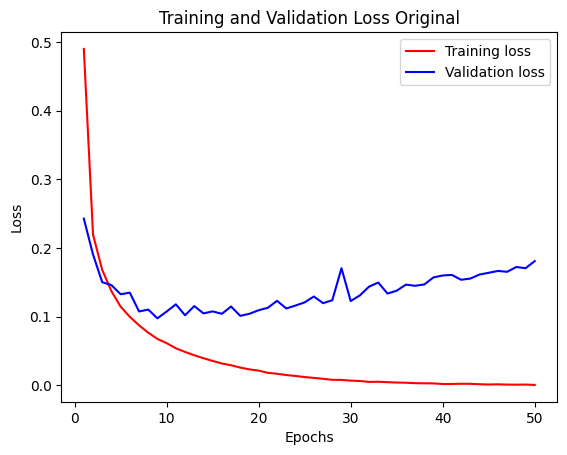

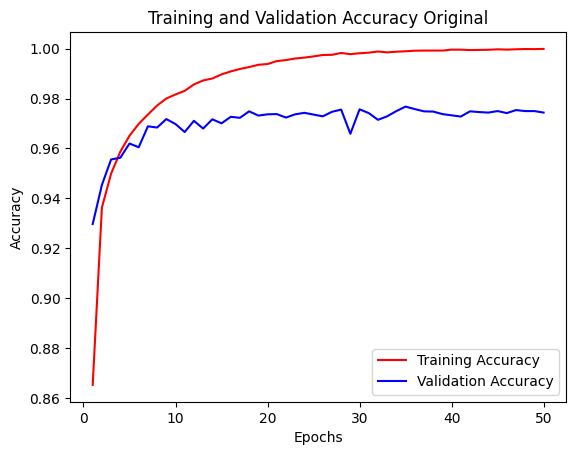

In [102]:
plotLoss(history_original,"Original")
plotAcc(history_original,"Original")

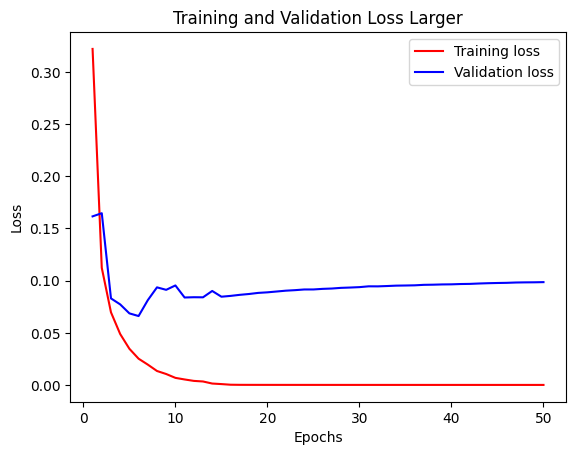

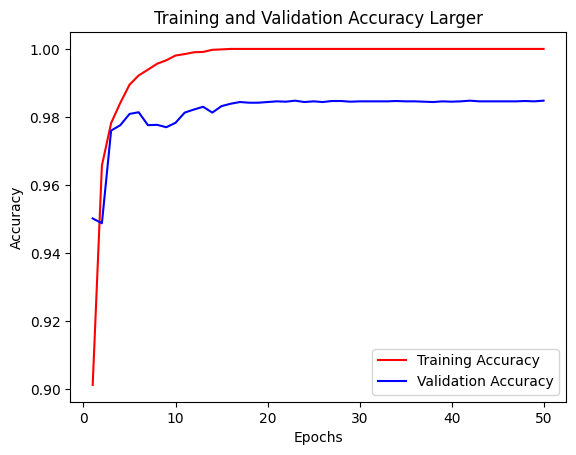

In [103]:
plotLoss(history_larger,"Larger")
plotAcc(history_larger,"Larger")

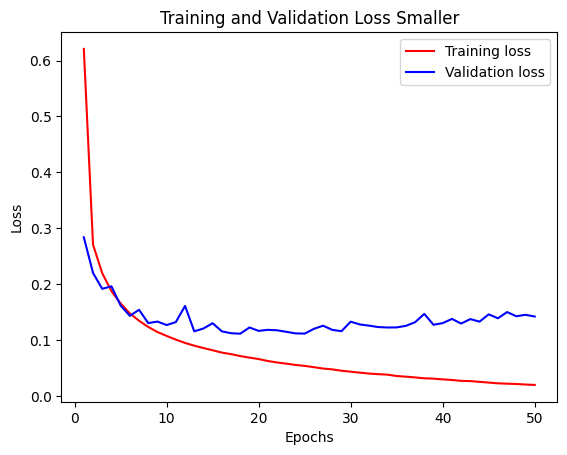

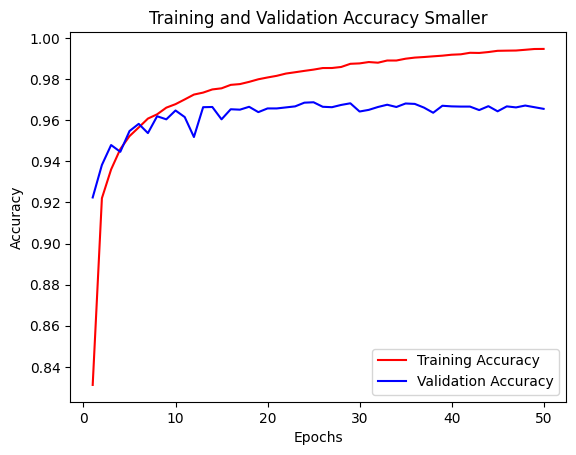

In [104]:
plotLoss(history_smaller,"Smaller")
plotAcc(history_smaller,"Smaller")

In [105]:
history_Dropout = buildModelDropout(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6236 - loss: 1.1385 - val_accuracy: 0.9015 - val_loss: 0.3505
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.8236 - loss: 0.5911 - val_accuracy: 0.9233 - val_loss: 0.2715
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.8591 - loss: 0.4844 - val_accuracy: 0.9373 - val_loss: 0.2200
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.8757 - loss: 0.4285 - val_accuracy: 0.9399 - val_loss: 0.2134
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.8844 - loss: 0.3998 - val_accuracy: 0.9463 - val_loss: 0.1957
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.8937 - loss: 0.3789 - val_accuracy: 0.9483 - val_loss: 0.1829
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.8977 - loss: 0.3575 - val_accuracy: 0.9507 - val_loss: 0.1765
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.9027 - loss: 0.3448 - va

In [106]:
history_Regularized = buildModelRegulalize(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8576 - loss: 0.6682 - val_accuracy: 0.9150 - val_loss: 0.4215
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - accuracy: 0.9301 - loss: 0.3728 - val_accuracy: 0.9368 - val_loss: 0.3445
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - accuracy: 0.9437 - loss: 0.3148 - val_accuracy: 0.9454 - val_loss: 0.3086
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9526 - loss: 0.2768 - val_accuracy: 0.9545 - val_loss: 0.2680
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.9581 - loss: 0.2515 - val_accuracy: 0.9583 - val_loss: 0.2550
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.9625 - loss: 0.2326 - val_accuracy: 0.9630 - val_loss: 0.2279
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.9651 - loss: 0.2175 - val_accuracy: 0.9602 - val_loss: 0.2352
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.9685 - loss: 0.2043 - va

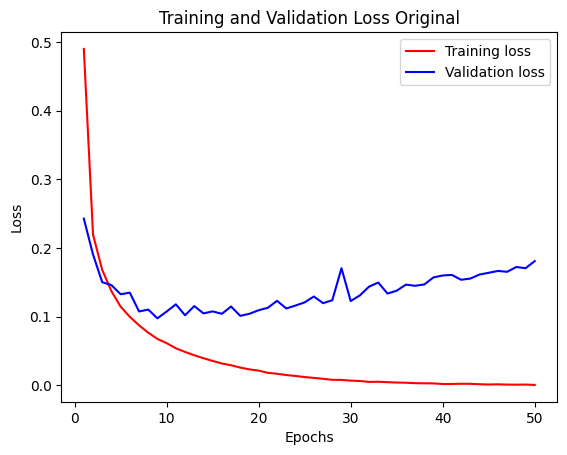

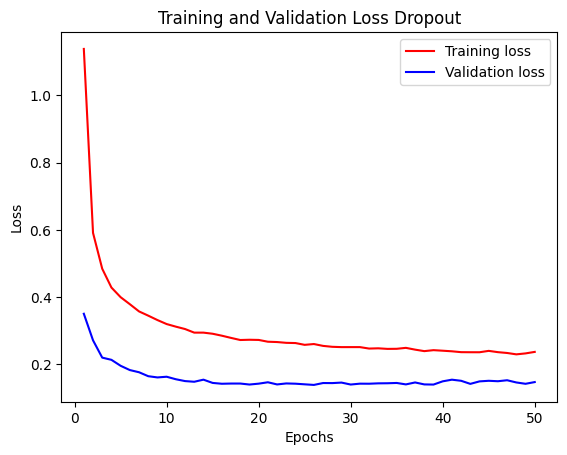

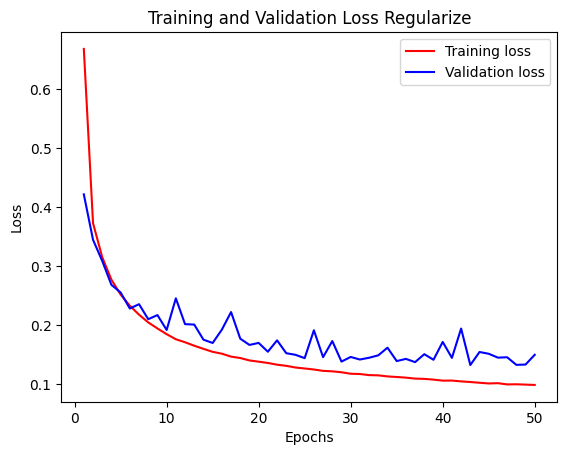

In [107]:
plotLoss(history_original,'Original')
plotLoss(history_Dropout,'Dropout')
plotLoss(history_Regularized,'Regularize')

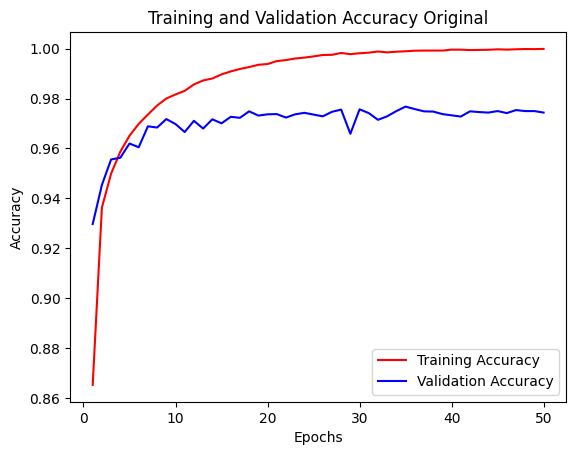

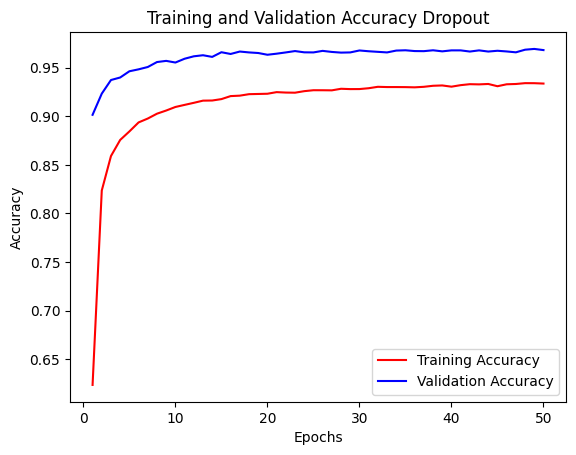

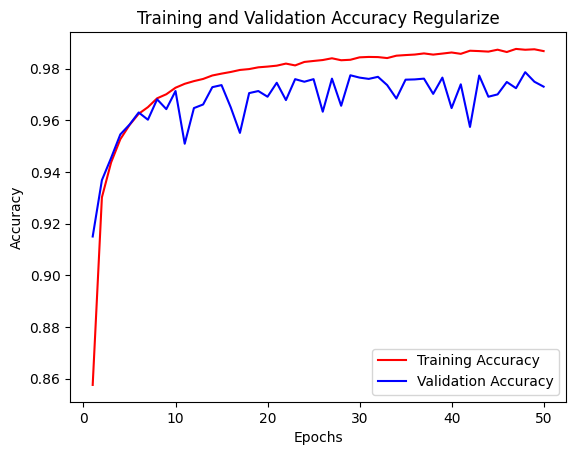

In [108]:
plotAcc(history_original,'Original')
plotAcc(history_Dropout,'Dropout')
plotAcc(history_Regularized,'Regularize')

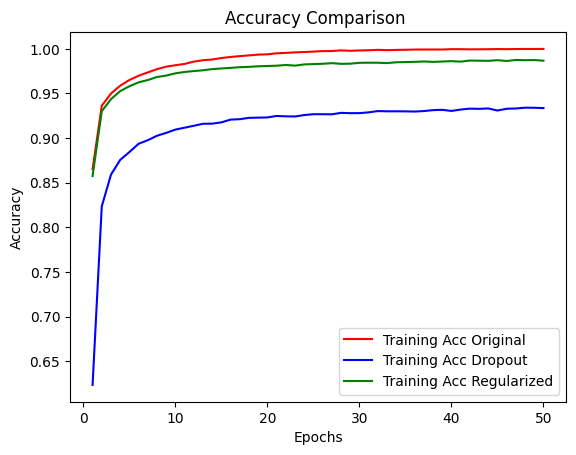

In [109]:
acc_ori = history_original.history['accuracy']
acc_DropOut = history_Dropout.history['accuracy']
acc_Regularized = history_Regularized.history['accuracy']
epochs = range(1,len(acc_ori)+1)
plt.plot(epochs,acc_ori,'r',label='Training Acc Original')
plt.plot(epochs,acc_DropOut,'b',label='Training Acc Dropout')
plt.plot(epochs,acc_Regularized,'g',label='Training Acc Regularized')
plt.title('Accuracy Comparison ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

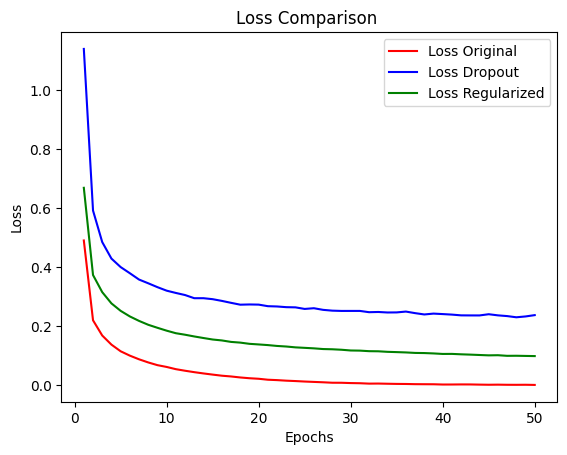

In [110]:
loss_ori = history_original.history['loss']
loss_DropOut = history_Dropout.history['loss']
loss_Regularized = history_Regularized.history['loss']
epochs = range(1,len(loss_ori)+1)
plt.plot(epochs,loss_ori,'r',label='Loss Original')
plt.plot(epochs,loss_DropOut,'b',label='Loss Dropout')
plt.plot(epochs,loss_Regularized,'g',label='Loss Regularized')
plt.title('Loss Comparison ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

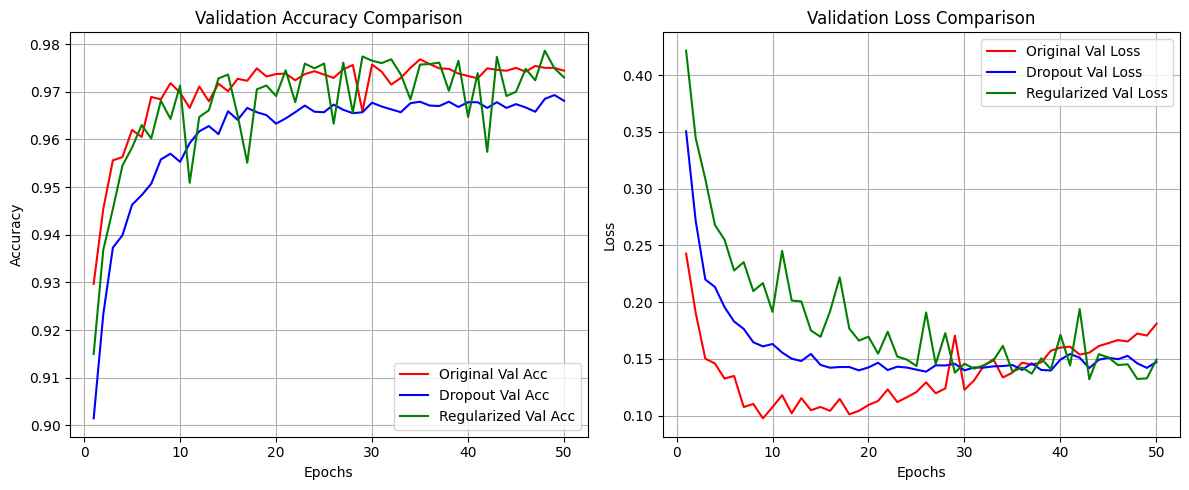

In [111]:
val_acc_ori = history_original.history['val_accuracy']
val_acc_drop = history_Dropout.history['val_accuracy']
val_acc_reg = history_Regularized.history['val_accuracy']

val_loss_ori = history_original.history['val_loss']
val_loss_drop = history_Dropout.history['val_loss']
val_loss_reg = history_Regularized.history['val_loss']

epochs = range(1, len(val_acc_ori) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, val_acc_ori, 'r', label='Original Val Acc')
plt.plot(epochs, val_acc_drop, 'b', label='Dropout Val Acc')
plt.plot(epochs, val_acc_reg, 'g', label='Regularized Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_loss_ori, 'r', label='Original Val Loss')
plt.plot(epochs, val_loss_drop, 'b', label='Dropout Val Loss')
plt.plot(epochs, val_loss_reg, 'g', label='Regularized Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [112]:
loss_ori , acc_ori = history_original.model.evaluate(test_x,test_y)
print(f"Loss : {loss_ori} , Acc : {acc_ori}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - accuracy: 0.9735 - loss: 0.1601
Loss : 0.16008451581001282 , Acc : 0.9735000133514404


In [113]:
loss_Large , acc_Large = history_larger.model.evaluate(test_x,test_y)
print(f"Loss : {loss_Large} , Acc : {acc_Large}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.9849 - loss: 0.0836
Loss : 0.08358465880155563 , Acc : 0.9848999977111816


In [114]:
loss_small , acc_small = history_smaller.model.evaluate(test_x,test_y)
print(f"Loss : {loss_small} , Acc : {acc_small}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - accuracy: 0.9657 - loss: 0.1464
Loss : 0.14642144739627838 , Acc : 0.9656999707221985


In [115]:
loss_dropout , acc_dropout = history_Dropout.model.evaluate(test_x,test_y)
print(f"Loss : {loss_dropout} , Acc : {acc_dropout}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - accuracy: 0.9622 - loss: 0.1537
Loss : 0.15371336042881012 , Acc : 0.9621999859809875


In [116]:
loss_Regularized , acc_Regularized = history_Regularized.model.evaluate(test_x,test_y)
print(f"Loss : {loss_Regularized} , Acc : {acc_Regularized}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.9721 - loss: 0.1448
Loss : 0.14483122527599335 , Acc : 0.972100019454956


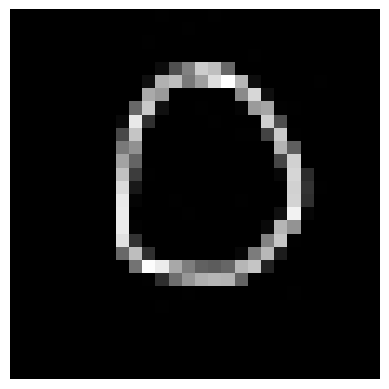

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ผลการทำนาย: เลข 0
ความมั่นใจ: 74.57%


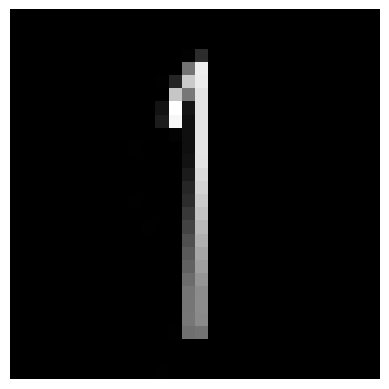

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 1
ความมั่นใจ: 99.94%


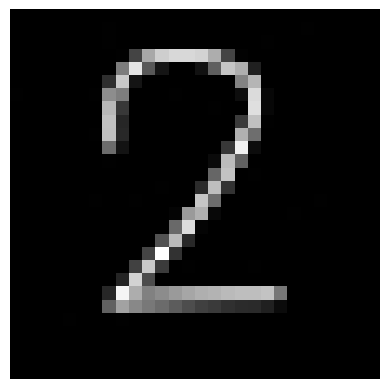

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 2
ความมั่นใจ: 87.31%


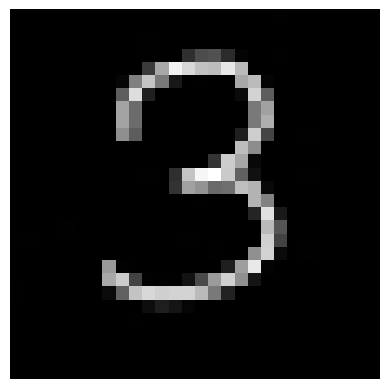

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
ผลการทำนาย: เลข 3
ความมั่นใจ: 100.00%


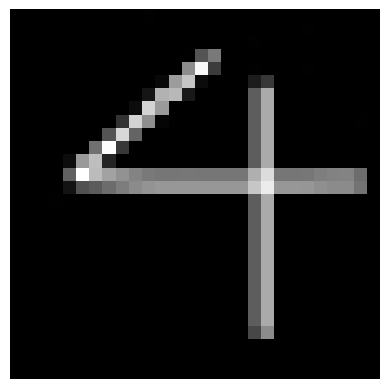

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 4
ความมั่นใจ: 75.92%


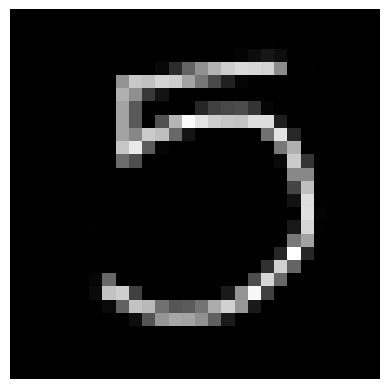

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 5
ความมั่นใจ: 99.78%


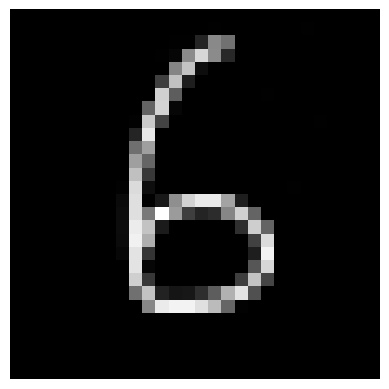

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 6
ความมั่นใจ: 99.99%


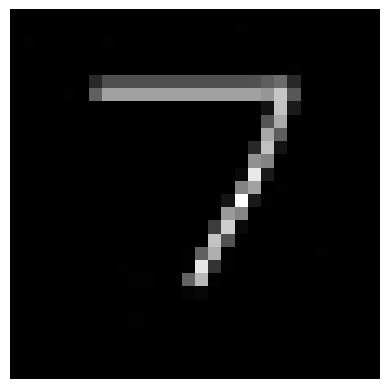

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 7
ความมั่นใจ: 75.48%


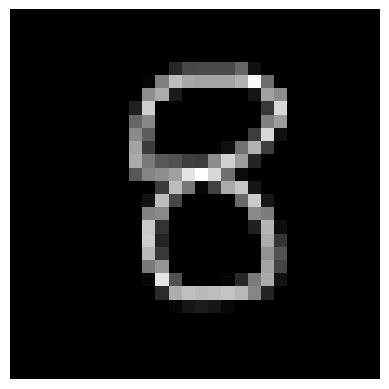

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
ผลการทำนาย: เลข 8
ความมั่นใจ: 99.86%


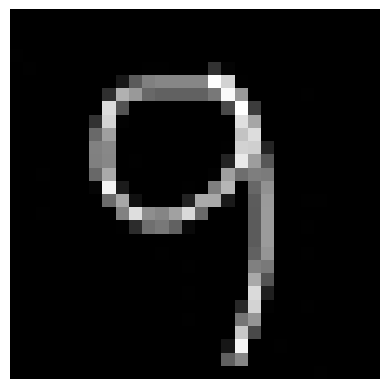

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
ผลการทำนาย: เลข 9
ความมั่นใจ: 99.99%


In [ ]:
for i in range(0,10) :
    filename = f"test{i}.jpg"
    img = load_img(filename,color_mode='grayscale',target_size=(28,28))

    img_array = img_to_array(img)
    img_array = 255.0 - img_array

    img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

    plt.imshow(img_array.reshape(28,28) , cmap='gray')
    plt.axis('off')
    plt.show()

    prediction = history_original.model.predict(img_array)
    predicted_digit = np.argmax(prediction)

    print(f"ผลการทำนาย: เลข {predicted_digit}")
    print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")